In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv", index_col="customerID")
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No


In [2]:
print("Null values per column:\n", df.isnull().sum())
total_nulls = df.isnull().sum().sum()
total_cells = np.prod(df.shape)
print("\nTotal nulls: ", total_nulls, "\nTotal cells: ", total_cells, "\nPercentage: ", (total_nulls / total_cells) * 100)

Null values per column:
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total nulls:  0 
Total cells:  140860 
Percentage:  0.0


In [3]:
print("Number of unique values:\n", df.nunique())

cols = list(df.columns)
print("\ncolumns: ", cols)

obj_cols = list(df.select_dtypes(include=['object']))
print("\nobject columns: ", obj_cols)

Number of unique values:
 gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

columns:  ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

object columns:  ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 

In [4]:
features = ['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
feat_df = df[features].copy()

print(feat_df.isnull().sum())
feat_df = feat_df.dropna(subset=["Churn"])

Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64


In [5]:
feat_obj_cols = [col for col in feat_df if col in obj_cols]
labels = {}
for col in feat_obj_cols:
    labels[col] = list(feat_df[col].unique())
    print(col, ": ", labels[col], "\n")    

Churn :  ['No', 'Yes'] 

gender :  ['Female', 'Male'] 

Partner :  ['Yes', 'No'] 

Dependents :  ['No', 'Yes'] 

PhoneService :  ['No', 'Yes'] 

MultipleLines :  ['No phone service', 'No', 'Yes'] 

InternetService :  ['DSL', 'Fiber optic', 'No'] 

OnlineSecurity :  ['No', 'Yes', 'No internet service'] 

OnlineBackup :  ['Yes', 'No', 'No internet service'] 

DeviceProtection :  ['No', 'Yes', 'No internet service'] 

TechSupport :  ['No', 'Yes', 'No internet service'] 

StreamingTV :  ['No', 'Yes', 'No internet service'] 

StreamingMovies :  ['No', 'Yes', 'No internet service'] 

Contract :  ['Month-to-month', 'One year', 'Two year'] 

PaperlessBilling :  ['Yes', 'No'] 

PaymentMethod :  ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'] 

TotalCharges :  ['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8', '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25', '528.35', 

In [6]:
# Cleaning Churn

feat_df['Churn'] = feat_df['Churn'].map({"Yes": 1, "No": 0}).astype(int)
print(feat_df['Churn'].dtype)
feat_df['Churn'].head()

int64


customerID
7590-VHVEG    0
5575-GNVDE    0
3668-QPYBK    1
7795-CFOCW    0
9237-HQITU    1
Name: Churn, dtype: int64

In [7]:
# Cleaning Dependents

feat_df['Dependents'] = feat_df['Dependents'].map({"Yes": 1, "No": 0}).astype(int)
print(feat_df['Dependents'].dtype)
feat_df['Dependents'].head()

int64


customerID
7590-VHVEG    0
5575-GNVDE    0
3668-QPYBK    0
7795-CFOCW    0
9237-HQITU    0
Name: Dependents, dtype: int64

In [8]:
# Cleaning Partner

feat_df['Partner'] = feat_df['Partner'].map({"Yes": 1, "No": 0}).astype(int)
print(feat_df['Partner'].dtype)
feat_df['Partner'].head()

int64


customerID
7590-VHVEG    1
5575-GNVDE    0
3668-QPYBK    0
7795-CFOCW    0
9237-HQITU    0
Name: Partner, dtype: int64

In [9]:
# Cleaning PhoneService and MultipleLines

print(feat_df[['MultipleLines', 'PhoneService']].isnull().sum(), '\n')
feat_df.loc[feat_df['MultipleLines'] == "No phone service", 'PhoneService'] = "No"

feat_df['MultipleLines'] = feat_df['MultipleLines'].map({'No phone service': "0", "Yes": 1, "No": 0}).astype(int)
feat_df['PhoneService'] = feat_df['PhoneService'].map({"Yes": 1, "No": 0}).astype(int)

print(feat_df[['MultipleLines', 'PhoneService']].isnull().sum())
feat_df[['MultipleLines', 'PhoneService']].head()

MultipleLines    0
PhoneService     0
dtype: int64 

MultipleLines    0
PhoneService     0
dtype: int64


,MultipleLines,PhoneService
customerID,,
7590-VHVEG,0,0
5575-GNVDE,0,1
3668-QPYBK,0,1
7795-CFOCW,0,0
9237-HQITU,0,1


In [10]:
# Cleaning dirty_cols

dirty_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
          'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in dirty_cols:
    feat_df.loc[feat_df[col] == "No internet service", 'InternetService'] = "No"

    feat_df[col] = feat_df[col].map({'No internet service': "0", "Yes": 1, "No": 0}).astype(int)

feat_df[['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
          'TechSupport', 'StreamingTV', 'StreamingMovies']].head()

,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
customerID,,,,,,
7590-VHVEG,0,1,0,0,0,0
5575-GNVDE,1,0,1,0,0,0
3668-QPYBK,1,1,0,0,0,0
7795-CFOCW,1,0,1,1,0,0
9237-HQITU,0,0,0,0,0,0


In [11]:
# Cleaning PaperlessBilling

feat_df['PaperlessBilling'] = feat_df['PaperlessBilling'].map({"Yes": 1, "No": 0}).astype(int)
print(feat_df['PaperlessBilling'].dtype)
feat_df['PaperlessBilling'].head()

int64


customerID
7590-VHVEG    1
5575-GNVDE    0
3668-QPYBK    1
7795-CFOCW    0
9237-HQITU    1
Name: PaperlessBilling, dtype: int64

In [12]:
# Cleaning TotalCharges 

feat_df['TotalCharges'] = feat_df['TotalCharges'].replace({" ": 0}).astype('float64')
print(feat_df['TotalCharges'].dtype)
print(feat_df['TotalCharges'].isnull().sum())
feat_df['TotalCharges'].head()

float64
0


customerID
7590-VHVEG      29.85
5575-GNVDE    1889.50
3668-QPYBK     108.15
7795-CFOCW    1840.75
9237-HQITU     151.65
Name: TotalCharges, dtype: float64

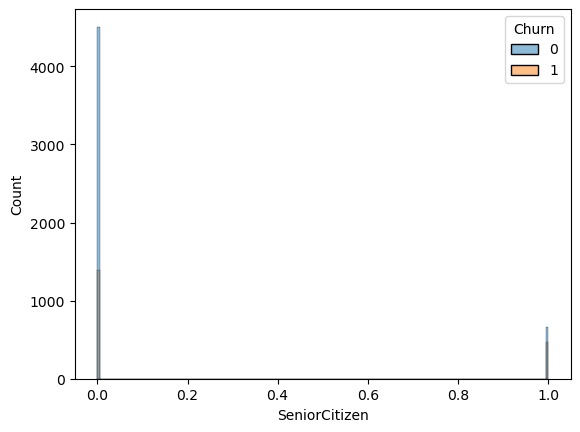

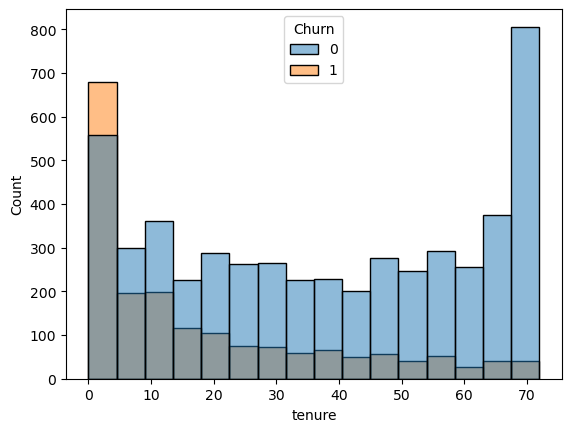

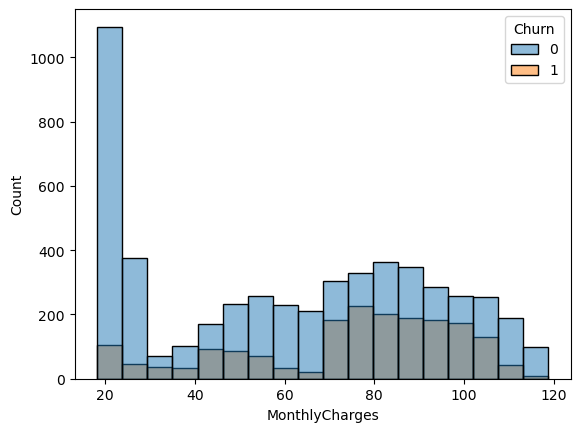

In [13]:
feat_cols = list(feat_df.columns)
clean_cols = [col for col in feat_df if col not in feat_obj_cols]
for col in clean_cols:
    sns.histplot(data=feat_df, x=col, hue="Churn")
    plt.show()

In [14]:
from sklearn.preprocessing import OneHotEncoder

feat_obj_cols = [col for col in feat_df if col in list(feat_df.select_dtypes(include=['object']))]

one_hot = OneHotEncoder(sparse_output=False)
feat_df_data = one_hot.fit_transform(feat_df[feat_obj_cols])
feat_df_encoded = pd.DataFrame(
    feat_df_data, 
    columns=one_hot.get_feature_names_out(feat_obj_cols),
    index=feat_df.index
)

feat_df_encoded

,gender_Female,gender_Male,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
customerID,,,,,,,,,,,,
7590-VHVEG,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
5575-GNVDE,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3668-QPYBK,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
7795-CFOCW,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
9237-HQITU,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6840-RESVB,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2234-XADUH,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4801-JZAZL,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [15]:
feat_non_obj_cols = [col for col in feat_df if col not in feat_obj_cols]
print(feat_non_obj_cols)

final_df = pd.merge(feat_df[feat_non_obj_cols], feat_df_encoded, on="customerID", how="inner")
final_df

['Churn', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges']


,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
customerID,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,0,1,0,1,0,0,0,1,0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
5575-GNVDE,0,0,0,0,34,1,0,1,0,1,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3668-QPYBK,1,0,0,0,2,1,0,1,1,0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
7795-CFOCW,0,0,0,0,45,0,0,1,0,1,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
9237-HQITU,1,0,0,0,2,1,0,0,0,0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6840-RESVB,0,0,1,1,24,1,1,1,0,1,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2234-XADUH,0,0,1,1,72,1,1,0,1,1,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4801-JZAZL,0,0,1,1,11,0,0,1,0,0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [16]:
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler

X = final_df.drop(columns=['Churn'])
y = final_df['Churn']

rus = RandomUnderSampler(sampling_strategy='auto',random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

X = X_resampled
y = y_resampled

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

print("X_train:\n", X_train.head())
print("\nX_val:\n", X_val.head())
print("\ny_train:\n", y_train.head())
print("\ny_val:\n", y_val.head())

X_train:
             SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
customerID                                                             
8481-YYXWG              0        0           0       5             1   
5590-YRFJT              0        1           0      20             0   
5644-PDMZC              1        0           0       2             1   
3129-AAQOU              0        1           1      19             1   
4484-CGXFK              0        0           0       3             1   

            MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  \
customerID                                                                  
8481-YYXWG              0               0             1                 0   
5590-YRFJT              0               0             0                 0   
5644-PDMZC              1               0             1                 0   
3129-AAQOU              1               0             0                 0   
4484-CGXFK             

In [17]:
print(X.dtypes)
mi_X = X.copy()
final_cols = list(X.columns)
# Convert float column 'col_name' to standard int64
mi_X[final_cols] = X[final_cols].round(0).astype('Int64')
print("\n", mi_X.dtypes)
discrete_features = mi_X.dtypes == int

SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
gender_Female                              float64
gender_Male                                float64
InternetService_DSL                        float64
InternetService_Fiber optic                float64
InternetService_No             

In [18]:
from sklearn.feature_selection import mutual_info_regression

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

mi_scores = make_mi_scores(X, y, discrete_features)

threshold = 0.006
selected_features = mi_scores[mi_scores > threshold].index.tolist()

print(f"Original feature count: {X.shape[1]}")
print(f"Features kept: {len(selected_features)}")
print(f"Features dropped: {X.shape[1] - len(selected_features)}\n")

X = X[selected_features]
# print(mi_scores[::3])
print(mi_scores[mi_scores >= threshold])

Original feature count: 27
Features kept: 17
Features dropped: 10

Contract_Month-to-month                    0.137997
tenure                                     0.101876
Contract_Two year                          0.090203
InternetService_Fiber optic                0.073604
PaymentMethod_Electronic check             0.062983
MonthlyCharges                             0.061288
PaperlessBilling                           0.060123
TotalCharges                               0.050722
InternetService_No                         0.044938
Contract_One year                          0.025180
StreamingMovies                            0.024626
TechSupport                                0.021870
Dependents                                 0.018644
InternetService_DSL                        0.017794
PaymentMethod_Bank transfer (automatic)    0.017118
Partner                                    0.016533
PaymentMethod_Credit card (automatic)      0.008475
Name: MI Scores, dtype: float64


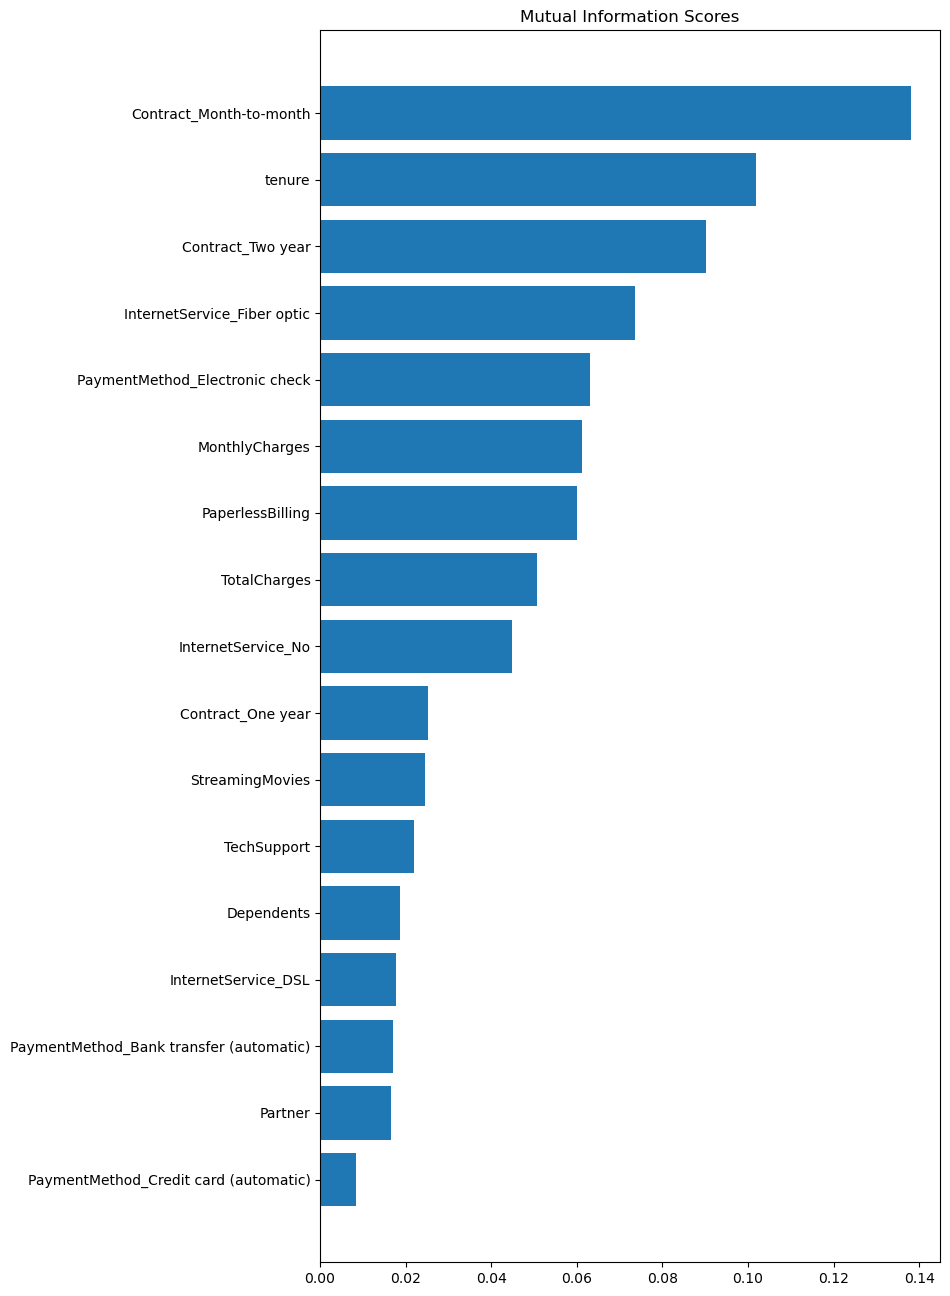

In [19]:
def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")


plt.figure(dpi=100, figsize=(8, 16))
plot_mi_scores(mi_scores[mi_scores >= threshold])

Accuracy score: 0.7553475935828877
Recall score: 0.776536312849162
              precision    recall  f1-score   support

           0       0.78      0.74      0.76       390
           1       0.73      0.78      0.75       358

    accuracy                           0.76       748
   macro avg       0.76      0.76      0.76       748
weighted avg       0.76      0.76      0.76       748



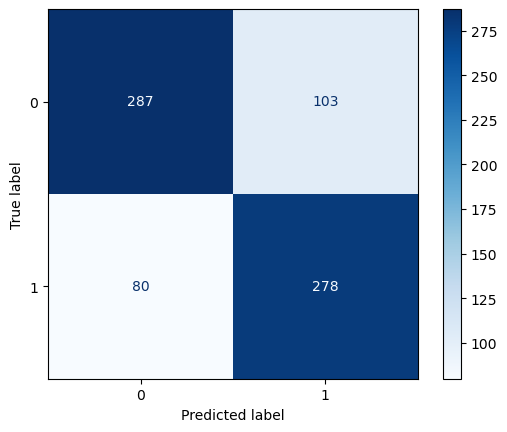

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict_proba(X_val)[:, 1]
chosen_cutoff = 0.5
rf_preds = (rf_preds >= chosen_cutoff).astype(int)

print('Accuracy score:', accuracy_score(y_val, rf_preds))
print('Recall score:', recall_score(y_val, rf_preds))
print(classification_report(y_val, rf_preds))
cm = confusion_matrix(y_val, rf_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Render plot
disp.plot(cmap=plt.cm.Blues)
plt.show()

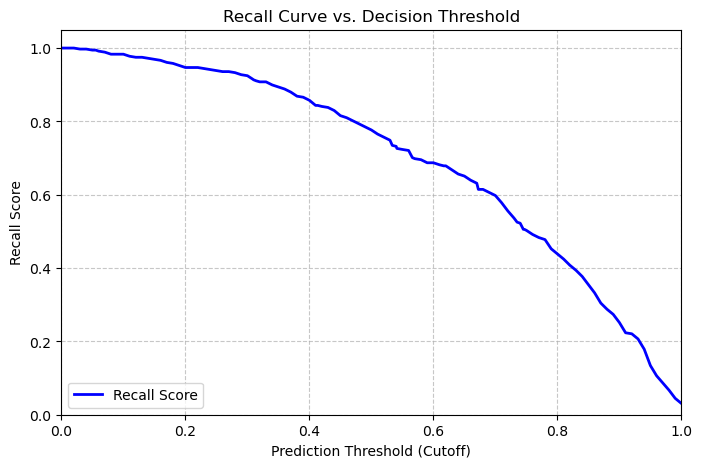

In [21]:
from sklearn.metrics import precision_recall_curve

y_probs = rf_model.predict_proba(X_val)[:, 1]

_, recalls, thresholds = precision_recall_curve(y_val, y_probs)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, recalls[:-1], label="Recall Score", color="blue", linewidth=2)

plt.title("Recall Curve vs. Decision Threshold")
plt.xlabel("Prediction Threshold (Cutoff)")
plt.ylabel("Recall Score")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(loc="lower left")
plt.show()

In [22]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Set up Stratified 5-Fold Cross-Validation
cv = StratifiedKFold(n_splits=25, shuffle=True, random_state=42)

# Run cross-validation
cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring="recall")

# Output results
print(f"All 5 fold scores: {cv_scores}")
print(f"Mean CV recall: {cv_scores.mean() * 100:.2f}%")
print(f"Score Variance (Standard Deviation): {cv_scores.std() * 100:.2f}%")

All 5 fold scores: [0.82666667 0.70666667 0.8        0.77333333 0.69333333 0.84
 0.73333333 0.76       0.77333333 0.73333333 0.77333333 0.77333333
 0.76       0.71621622 0.83783784 0.77027027 0.72972973 0.75675676
 0.77027027 0.74666667 0.81333333 0.81333333 0.68       0.78666667
 0.69333333]
Mean CV recall: 76.24%
Score Variance (Standard Deviation): 4.39%
